# Проект. Исследование стартапов
- Автор: Карманов Владимир
- Дата: 31.03.2026

## Введение

Поле для вашего введения: опишите контекст и цели проекта. Чтобы изменить содержимое ячейки, дважды нажмите на неё или нажмите «Ввод».

Цель: провести анализ данных, исследовать динамику и структуру финансирования стартапов и помочь финансовой компании, работающей с венчурными инвестициями, выйти на рынок с покупкой и развитием компаний. 

Описание проекта:
- Знакомство с данными
- Инжиниринг признаков
- Работа с выбросами и анализ
- Анализ динамики
- Итоговый вывод и рекомендации

## Шаг 1. Знакомство с данными: загрузка и предобработка

Датасет получен из базы данных стартапов.

Название основного датасета — `cb_investments.zip`. Внутри архива один файл — `cb_investments.csv`.

Описание данных:
* `name` — название компании.
* `homepage_url` — ссылка на сайт компании.
* `category_list` — категории, в которых работает компания. Указываются через `|`.
* `market` — основной рынок или отрасль компании.
* `funding_total_usd` — общий объём привлечённых инвестиций в долларах США.
* `status` — текущий статус компании, например `operating`, `closed` и так далее.
* `country_code` — код страны, например USA.
* `state_code` — код штата или региона, например, CA.
* `region` — регион, например, SF Bay Area.
* `city` — город, в котором расположена компания.
* `funding_rounds` — общее число раундов финансирования.
* `participants` — число участников в раундах финансирования.
* `founded_at` — дата основания компании.
* `founded_month` — месяц основания в формате `YYYY-MM`.
* `founded_quarter` — квартал основания в формате `YYYY-QN`.
* `founded_year` — год основания.
* `first_funding_at` — дата первого финансирования.
* `mid_funding_at` — дата среднего по времени раунда финансирования.
* `last_funding_at` — дата последнего финансирования.
* `seed` — сумма инвестиций на посевной стадии.
* `venture` — сумма венчурных инвестиций.
* `equity_crowdfunding` — сумма, привлечённая через долевой краудфандинг.
* `undisclosed` — сумма финансирования нераскрытого типа.
* `convertible_note` — сумма инвестиций через конвертируемые займы.
* `debt_financing` — сумма долгового финансирования.
* `angel` — сумма инвестиций от бизнес-ангелов.
* `grant` — сумма полученных грантов.
* `private_equity` — сумма инвестиций в виде прямых (частных) вложений.
* `post_ipo_equity` — сумма финансирования после IPO.
* `post_ipo_debt` — сумма долгового финансирования после IPO.
* `secondary_market` — сумма сделок на вторичном рынке.
* `product_crowdfunding` — сумма, привлечённая через продуктовый краудфандинг.
* `round_A` — `round_H` — сумма инвестиций в соответствующем раунде.

Название дополнительного датасета — `cb_returns.csv`. Он содержит суммы возвратов по типам финансирования в миллионах долларов по годам.

Описание данных:
* `year` — год возврата средств.
* `seed` — сумма возвратов от посевных инвестиций.
* `venture` — сумма возвратов от венчурных инвестиций.
* `equity_crowdfunding` — сумма, возвращённая по долевому краудфандингу.
* `undisclosed` — сумма возвратов нераскрытого типа.
* `convertible_note` — сумма возвратов через конвертируемые займы.
* `debt_financing` — сумма возвратов от долгового финансирования.
* `angel` — сумма возвратов бизнес-ангелам.
* `grant` — сумма возвратов по грантам.
* `private_equity` — сумма возвратов прямых (частных) вложений.
* `post_ipo_equity` — сумма возвратов от IPO.
* `post_ipo_debt` — сумма возвратов от долгового IPO.
* `secondary_market` — сумма возвратов от сделок на вторичном рынке.
* `product_crowdfunding` — сумма возвратов по продуктовому краудфандингу.

Файлы находятся в папке `datasets`, если вы выполняете работу на платформе. В случае, если вы делаете работу локально, доступ к файлам в папке можно получить по адресу `https://code.s3.yandex.net/datasets/` + имя файла.

### 1.1. Вывод общей информации

Загрузите необходимые для работы библиотеки.

Совет: если вы неоднократно используете какой-либо код, вынесите его в начало проекта в виде функций.

In [1]:
# Импортируем библиотеки
import pandas as pd
import numpy as np
# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

Загрузите все данные по проекту.

Совет: данные из zip-архива можно загрузить следующим кодом:

`df = pd.read_csv("https://code.s3.yandex.net/datasets/cb_investments.zip", sep=';', low_memory=False)`

In [2]:
# Загружаем датасеты
df = pd.read_csv("https://code.s3.yandex.net/datasets/cb_investments.zip", sep=';', low_memory=False)
df_ret = pd.read_csv("https://code.s3.yandex.net/datasets/cb_returns.csv")

Выведите информацию, которая необходима для принятия решений о предобработке.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  49437 non-null  object 
 1   homepage_url          45989 non-null  object 
 2   category_list         45477 non-null  object 
 3    market               45477 non-null  object 
 4    funding_total_usd    49438 non-null  object 
 5   status                48124 non-null  object 
 6   country_code          44165 non-null  object 
 7   state_code            30161 non-null  object 
 8   region                44165 non-null  object 
 9   city                  43322 non-null  object 
 10  funding_rounds        49438 non-null  float64
 11  participants          30473 non-null  float64
 12  founded_at            38554 non-null  object 
 13  founded_month         38482 non-null  object 
 14  founded_quarter       38482 non-null  object 
 15  founded_year       

In [4]:
df.head()

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,Harvard University,http://harvard.edu,|Education|,Education,"9,00,00,000",operating,USA,MA,Boston,Cambridge,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,University of New Brunswick,http://www.unb.ca,NaN,NaN,"20,00,000",operating,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,"90,00,000",operating,USA,DE,"Wilmington, Delaware",Wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,University of Michigan,http://www.umich.edu/,|Education|,Education,"77,00,000",operating,USA,MI,Detroit,Ann Arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,"5,40,000",operating,USA,OH,Cleveland,Cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
df_ret.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  15 non-null     int64  
 1   seed                  15 non-null     float64
 2   venture               15 non-null     float64
 3   equity_crowdfunding   15 non-null     float64
 4   undisclosed           15 non-null     float64
 5   convertible_note      15 non-null     float64
 6   debt_financing        15 non-null     float64
 7   angel                 15 non-null     float64
 8   grant                 15 non-null     float64
 9   private_equity        15 non-null     float64
 10  post_ipo_equity       15 non-null     float64
 11  post_ipo_debt         15 non-null     float64
 12  secondary_market      15 non-null     float64
 13  product_crowdfunding  15 non-null     float64
dtypes: float64(13), int64(1)
memory usage: 1.8 KB


In [6]:
df_ret.head()

,year,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
0,2000,16.70,55.40,0.0,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.0,0.20,0.0
1,2001,2.88,23.49,0.0,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.0,0.46,0.0
2,2002,6.59,209.42,0.0,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.0,0.06,0.0
3,2003,7.74,233.86,0.0,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.0,0.08,0.0
4,2004,9.93,555.90,0.0,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.0,0.55,0.0


In [7]:
# Считает пропуски в датасете cb_investments.zip
df.isna().sum()

name                     4857
homepage_url             8305
category_list            8817
 market                  8817
 funding_total_usd       4856
status                   6170
country_code            10129
state_code              24133
region                  10129
city                    10972
funding_rounds           4856
participants            23821
founded_at              15740
founded_month           15812
founded_quarter         15812
founded_year            15740
first_funding_at         4856
mid_funding_at          24006
last_funding_at          4856
seed                     4856
venture                  4856
equity_crowdfunding      4856
undisclosed              4856
convertible_note         4856
debt_financing           4856
angel                    4856
grant                    4856
private_equity           4856
post_ipo_equity          4856
post_ipo_debt            4856
secondary_market         4856
product_crowdfunding     4856
round_A                  4856
round_B   

In [8]:
# Подсчитываем долю строк с пропусками
df.isna().sum() / df.shape[0]

name                    0.089457
homepage_url            0.152963
category_list           0.162394
 market                 0.162394
 funding_total_usd      0.089439
status                  0.113641
country_code            0.186558
state_code              0.444487
region                  0.186558
city                    0.202085
funding_rounds          0.089439
participants            0.438741
founded_at              0.289903
founded_month           0.291229
founded_quarter         0.291229
founded_year            0.289903
first_funding_at        0.089439
mid_funding_at          0.442148
last_funding_at         0.089439
seed                    0.089439
venture                 0.089439
equity_crowdfunding     0.089439
undisclosed             0.089439
convertible_note        0.089439
debt_financing          0.089439
angel                   0.089439
grant                   0.089439
private_equity          0.089439
post_ipo_equity         0.089439
post_ipo_debt           0.089439
secondary_

In [9]:
# Считает пропуски в датасете cb_returns
df_ret.isna().sum()

year                    0
seed                    0
venture                 0
equity_crowdfunding     0
undisclosed             0
convertible_note        0
debt_financing          0
angel                   0
grant                   0
private_equity          0
post_ipo_equity         0
post_ipo_debt           0
secondary_market        0
product_crowdfunding    0
dtype: int64

In [10]:
# Понижаем разрядность числовых данных в датасете cb_investments.zip
for column in ['funding_rounds', 'participants', 'founded_year', 'seed', 'venture', 'equity_crowdfunding', 'undisclosed',
              'convertible_note', 'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity', 'post_ipo_debt', 
              'secondary_market', 'product_crowdfunding', 'round_A', 'round_B', 'round_C', 'round_D', 'round_E', 'round_F', 
              'round_G', 'round_H']:
    df[column] = pd.to_numeric(df[column], downcast='float')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  49437 non-null  object 
 1   homepage_url          45989 non-null  object 
 2   category_list         45477 non-null  object 
 3    market               45477 non-null  object 
 4    funding_total_usd    49438 non-null  object 
 5   status                48124 non-null  object 
 6   country_code          44165 non-null  object 
 7   state_code            30161 non-null  object 
 8   region                44165 non-null  object 
 9   city                  43322 non-null  object 
 10  funding_rounds        49438 non-null  float32
 11  participants          30473 non-null  float32
 12  founded_at            38554 non-null  object 
 13  founded_month         38482 non-null  object 
 14  founded_quarter       38482 non-null  object 
 15  founded_year       

In [12]:
# Понижаем разрядность числовых данных в датасете cb_returns
for column in ['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant',
              'private_equity', 'post_ipo_equity', 'post_ipo_debt', 'secondary_market', 'product_crowdfunding']:
    df_ret[column] = pd.to_numeric(df_ret[column], downcast='float')

In [13]:
df_ret['year'] = pd.to_numeric(df_ret['year'], downcast='integer')

In [14]:
df_ret.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  15 non-null     int16  
 1   seed                  15 non-null     float32
 2   venture               15 non-null     float32
 3   equity_crowdfunding   15 non-null     float32
 4   undisclosed           15 non-null     float32
 5   convertible_note      15 non-null     float32
 6   debt_financing        15 non-null     float32
 7   angel                 15 non-null     float32
 8   grant                 15 non-null     float32
 9   private_equity        15 non-null     float32
 10  post_ipo_equity       15 non-null     float32
 11  post_ipo_debt         15 non-null     float32
 12  secondary_market      15 non-null     float32
 13  product_crowdfunding  15 non-null     float32
dtypes: float32(13), int16(1)
memory usage: 938.0 bytes


Сделайте вывод о полученных данных: каков их объём, соответствуют ли данные описанию, есть ли пропущенные значения, используются ли верные типы данных. Отметьте другие особенности данных, которые вы обнаружите на этой стадии и на которые стоит обратить внимание при предобработке.

Промежуточный вывод:

`cb_investments.zip`:
- имеет 54294 строки и 40 колонок
- имеется большое количество пропусков в каждом столбце
- нужна замена у `funding_total_usd` с типа данных с `object` на числовой тип данных `float`(это будет дальше)
- уменьшил разрядность столбцов с  `float64` на `float32`

`cb_returns`:
- имеет 15 строк и 14 колонок
- не имеет пропусков
- понизил разрядность типов данных с `int64` на `int16` и `float64` на `float32`

### 1.2. Предобработка данных

Проверьте названия столбцов в датасетах: все ли они точно отражают содержимое данных и оформлены в удобном для работы стиле. При необходимости приведите их к единому аккуратному стилю.

In [15]:
# Проверяем стоблцы у cb_investments
df.columns

Index(['name', 'homepage_url', 'category_list', ' market ',
       ' funding_total_usd ', 'status', 'country_code', 'state_code', 'region',
       'city', 'funding_rounds', 'participants', 'founded_at', 'founded_month',
       'founded_quarter', 'founded_year', 'first_funding_at', 'mid_funding_at',
       'last_funding_at', 'seed', 'venture', 'equity_crowdfunding',
       'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding', 'round_A', 'round_B',
       'round_C', 'round_D', 'round_E', 'round_F', 'round_G', 'round_H'],
      dtype='object')

In [16]:
# Видим, что есть пробелы в столбцах market и funding_total_usd, а в остальном стобцы выглядят нормально
df.columns = df.columns.str.strip() 

In [17]:
# Проверяем и видим, что всё хорошо
df.columns

Index(['name', 'homepage_url', 'category_list', 'market', 'funding_total_usd',
       'status', 'country_code', 'state_code', 'region', 'city',
       'funding_rounds', 'participants', 'founded_at', 'founded_month',
       'founded_quarter', 'founded_year', 'first_funding_at', 'mid_funding_at',
       'last_funding_at', 'seed', 'venture', 'equity_crowdfunding',
       'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding', 'round_A', 'round_B',
       'round_C', 'round_D', 'round_E', 'round_F', 'round_G', 'round_H'],
      dtype='object')

In [18]:
# Проверяем у датасета cb_returns и видим, что тут всё хорошо
df_ret.columns

Index(['year', 'seed', 'venture', 'equity_crowdfunding', 'undisclosed',
       'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding'],
      dtype='object')

Уберите в столбце `funding_total_usd` выделение разрядов и приведите его к числовому типу.

In [19]:
# Меняем тип данных на числовой
df['funding_total_usd'] = df['funding_total_usd'].str.replace(',','')
df['funding_total_usd'] = pd.to_numeric(df['funding_total_usd'], errors='coerce')

In [20]:
# Проверяем
df['funding_total_usd'].dtype

dtype('float64')

In [21]:
# Уменьшаем разрядность
df['funding_total_usd'] = pd.to_numeric(df['funding_total_usd'], downcast='float')

In [22]:
# Проверяем
df['funding_total_usd'].dtype

dtype('float32')

Обработайте типы данных в столбцах, которые хранят значения даты и времени, если это необходимо.

In [23]:
# Меняем тип данных у founded_month
df['founded_month'] = pd.to_datetime(df['founded_month'], format='%Y-%m') 

In [24]:
df['founded_month'].dtype

dtype('<M8[ns]')

In [25]:
# Меняем тип данных у founded_at
df['founded_at'] = pd.to_datetime(df['founded_at'], format='%Y-%m-%d', errors='coerce')

In [26]:
df['founded_at'].dtype

dtype('<M8[ns]')

In [27]:
# Их не стану трогать, так как в pandas нет формата YYYY-QN
df['founded_quarter'].unique()

array([nan, '1902-Q1', '1903-Q1', '1905-Q1', '1906-Q1', '1907-Q1',
       '1908-Q1', '1910-Q1', '1911-Q1', '1912-Q1', '1912-Q2', '1913-Q1',
       '1914-Q1', '1917-Q1', '1918-Q1', '1919-Q1', '1919-Q2', '1920-Q1',
       '1921-Q1', '1922-Q1', '1922-Q3', '1923-Q1', '1924-Q1', '1924-Q4',
       '1925-Q1', '1926-Q1', '1928-Q1', '1929-Q1', '1930-Q1', '1933-Q1',
       '1934-Q1', '1936-Q1', '1937-Q1', '1938-Q1', '1939-Q1', '1941-Q1',
       '1943-Q1', '1944-Q1', '1945-Q1', '1946-Q1', '1947-Q1', '1948-Q1',
       '1949-Q1', '1950-Q1', '1951-Q1', '1952-Q1', '1953-Q1', '1954-Q1',
       '1955-Q1', '1956-Q1', '1957-Q1', '1958-Q1', '1959-Q1', '1960-Q1',
       '1960-Q2', '1961-Q1', '1961-Q3', '1962-Q1', '1962-Q3', '1963-Q1',
       '1963-Q3', '1964-Q1', '1965-Q1', '1966-Q1', '1967-Q1', '1967-Q2',
       '1968-Q1', '1969-Q1', '1969-Q2', '1969-Q3', '1970-Q1', '1970-Q2',
       '1971-Q1', '1972-Q1', '1972-Q2', '1973-Q1', '1973-Q2', '1973-Q3',
       '1973-Q4', '1974-Q1', '1974-Q4', '1975-Q1', '1975-

In [28]:
# Меняем тип данных у first_funding_at, mid_funding_at, last_funding_at
df['first_funding_at'] = pd.to_datetime(df['first_funding_at'], format='%Y-%m-%d', errors='coerce')
df['mid_funding_at'] = pd.to_datetime(df['mid_funding_at'], format='%Y-%m-%d', errors='coerce') 
df['last_funding_at'] = pd.to_datetime(df['last_funding_at'], format='%Y-%m-%d', errors='coerce')  

В датасете `cb_returns` сделайте столбец `year` индексом всего датасета, если не делали это при загрузке.

In [29]:
# Проверяем на уникальность year
print(df_ret['year'].is_unique)  # True, если все значения уникальны

True


In [30]:
# Делаем year индексом
df_ret = df_ret.set_index('year')

In [31]:
# Проверяем
print(df_ret.index)

Int64Index([2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010,
            2011, 2012, 2013, 2014],
           dtype='int64', name='year')


Обработайте текстовые данные, если это необходимо. Пропуски в текстовых столбцах заполните заглушками там, где это понадобится.

`Пропуски есть в каждом столбце в большом количестве, поэтому решил, что трогать их не буду, чтобы не искажать данные.`

Обработайте полные дубликаты в данных и пропуски в `funding_total_usd`. избавьтесь от тех строк, которые не несут какой-либо информации либо не содержат данных о финансировании.

In [32]:
# Находим полные дубликаты в датасете cb_investments
df.duplicated().sum()
print(f"Количество полных дубликатов: {df.duplicated().sum()} ")

Количество полных дубликатов: 4855 


In [33]:
# Удаляем их
df = df.drop_duplicates()

In [34]:
# Проверяем
df.duplicated().sum()

0

In [35]:
# Находим полные дубликаты в датасете cb_returns
df_ret.duplicated().sum()

0

In [36]:
# Удаляем строки, где пропуски в funding_total_usd
df = df.dropna(subset=['funding_total_usd'])

In [37]:
# Проверяем наличие неявных дубликатов у Software
df[df['market'].str.contains(r'^\s*Software\s*$', na=False)][['market']].value_counts()

market     
 Software      4190
Software        240
Software        137
 Software       125
Software         81
 Software        39
dtype: int64

In [38]:
# Удаляем пробелы в начале и конце строки в столбце market
df['market'] = df['market'].str.strip()

In [39]:
# Проверяем
df[df['market'].str.contains(r'^\s*Software\s*$', na=False)][['market']].value_counts()

market  
Software    4812
dtype: int64

In [40]:
# Проверяем и видим, что количество строк уменьшилось
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 40907 entries, 0 to 49437
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   name                  40906 non-null  object        
 1   homepage_url          38593 non-null  object        
 2   category_list         38404 non-null  object        
 3   market                38404 non-null  object        
 4   funding_total_usd     40907 non-null  float32       
 5   status                39802 non-null  object        
 6   country_code          37088 non-null  object        
 7   state_code            25619 non-null  object        
 8   region                37088 non-null  object        
 9   city                  36402 non-null  object        
 10  funding_rounds        40907 non-null  float32       
 11  participants          27331 non-null  float32       
 12  founded_at            32200 non-null  datetime64[ns]
 13  founded_month   

Заполните пропуски в значениях `mid_funding_at` на основании значений в столбцах `first_funding_at` и `last_funding_at`. В качестве нового значения вместо пропусков возьмите приблизительно середину интервала между этими двумя датами.

Оцените размер оставшихся пропусков в столбце.

In [41]:
# Находим строки с пропусками в mid_funding_at
missing_mid = df[df['mid_funding_at'].isna()]

# Вычисляем середину интервала (в наносекундах, чтобы избежать проблем с timedelta)
mid_dates = df['first_funding_at'] + ((df['last_funding_at'] - df['first_funding_at']) / 2)
# Заполняем пропуски в mid_funding_at
df['mid_funding_at'] = df['mid_funding_at'].fillna(mid_dates)

# Проверка: убедимся, что пропуски заполнены
print(f"Пропусков в mid_funding_at осталось: {df['mid_funding_at'].isna().sum()}")

Пропусков в mid_funding_at осталось: 1


Остался всего 1 пропуск в столбце `mid_funding_at`.

Оцените полноту данных и сделайте предварительный вывод о том, достаточно ли данных для решения задач проекта. Какой процент данных был отброшен?

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 40907 entries, 0 to 49437
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   name                  40906 non-null  object        
 1   homepage_url          38593 non-null  object        
 2   category_list         38404 non-null  object        
 3   market                38404 non-null  object        
 4   funding_total_usd     40907 non-null  float32       
 5   status                39802 non-null  object        
 6   country_code          37088 non-null  object        
 7   state_code            25619 non-null  object        
 8   region                37088 non-null  object        
 9   city                  36402 non-null  object        
 10  funding_rounds        40907 non-null  float32       
 11  participants          27331 non-null  float32       
 12  founded_at            32200 non-null  datetime64[ns]
 13  founded_month   

Отбросили большое количество данных, которые были дубликатами или не несли информации о финансировании, стало на 13387 строк меньше, что составляет около 25% данных, но теперь пропусков намного меньше, по сравнению с тем, что было раньше.

## Шаг 2. Инжиниринг признаков

При выполнении заданий не забывайте интерпретировать полученные результаты и делать промежуточные выводы.

### 2.1. Группы по срокам финансирования

Разделите все компании на три группы:

* Единичное финансирование — был всего один раунд финансирования.

* Срок финансирования до года — между первым и последним раундом финансирования прошло не более года.

* Срок финансирования более года.

Визуализируйте соотношение этих групп, создав два графика:

* По количеству компаний: Покажите, какой процент от общего числа компаний относится к каждой из трёх групп.
* По объёму инвестиций: Отобразите, какую долю от общего объёма привлечённых средств получила каждая группа.

Совет: Для ясности и согласованности используйте единую цветовую палитру для всех графиков, чтобы каждая категория (например, «Единичное финансирование») всегда отображалась одним цветом.

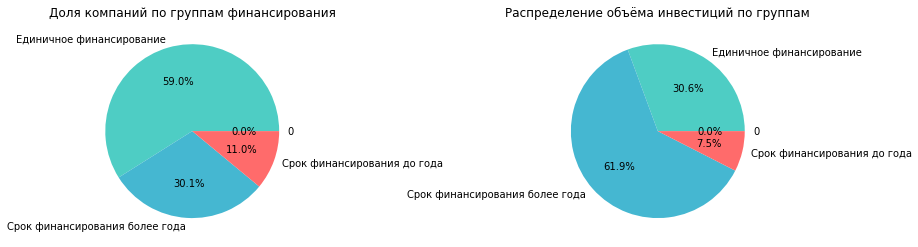

In [43]:
# Вычисляем разницу между последним и первым раундом (в днях)
df['funding_duration_days'] = (df['last_funding_at'] - df['first_funding_at']).dt.days

# Определяем группы
conditions = [
    (df['funding_rounds'] == 1),  # единичное финансирование — только один раунд
    df['funding_duration_days'].le(365),  # срок ≤ года
    df['funding_duration_days'].gt(365)   # срок > года
]

choices = [
    'Единичное финансирование',
    'Срок финансирования до года',
    'Срок финансирования более года'
]

df['funding_group'] = np.select(conditions, choices)

group_counts = df['funding_group'].value_counts().sort_index()
total_companies = len(df)
percentages = (group_counts / total_companies * 100).round(2)

investment_by_group = df.groupby('funding_group')['funding_total_usd'].sum()# берём funding_total_usd — общий объём привлечённых инвестиций
total_investments = investment_by_group.sum()
investment_shares = (investment_by_group / total_investments * 100).round(2)

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1'] # красный, зелёный, синий

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# График 1: доля компаний (%)
ax1.pie(percentages, labels=percentages.index, autopct='%1.1f%%', colors=colors)
ax1.set_title('Доля компаний по группам финансирования')

# График 2: доля объёма инвестиций (%)
ax2.pie(investment_shares, labels=investment_shares.index, autopct='%1.1f%%', colors=colors)
ax2.set_title('Распределение объёма инвестиций по группам')

plt.tight_layout()
plt.show()
 

Доля компаний по группам финансирования:
- около 59% у Единичного финансирования
- около 30% у Срока финансирования более года
- около 11% у Срока финасирования до года

Распределение объёма инвестиций по группам:
- около 61.9% у Срока финасирования более года
- около 30.6% у Единичного финасирования
- около 7.5% у Срока финансирования до года

Из этого можно сделать вывод: что финансируют чаще всего единично, но не огромные суммы, по сравнению с финансированием более года.

### 2.2 Выделение средних и нишевых сегментов рынка

Компании указывают свой сегмент рынка в столбце `market`. Рассчитайте, как часто в датасете встречается каждый из сегментов. Сегменты, к которым относится более 120 компаний, отнесите к массовым, сегменты, в которые входит от 35 до 120 включительно, отнесите к средним, а сегменты до 35 компаний отнесите к нишевым. Рассчитайте, сколько сегментов попадает в каждую из категорий.

Постройте график распределения количества компаний в сегментах и отобразите на нём разделение на нишевые и средние сегменты.

Суммарное количество компаний по категориям:
market
нишевый       830
средний      3841
массовый    33733
Name: market, dtype: int64


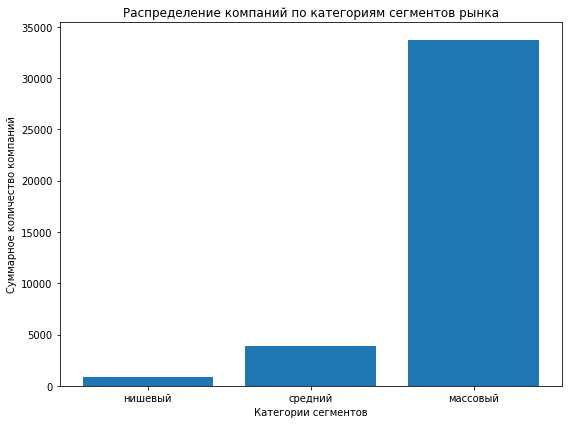

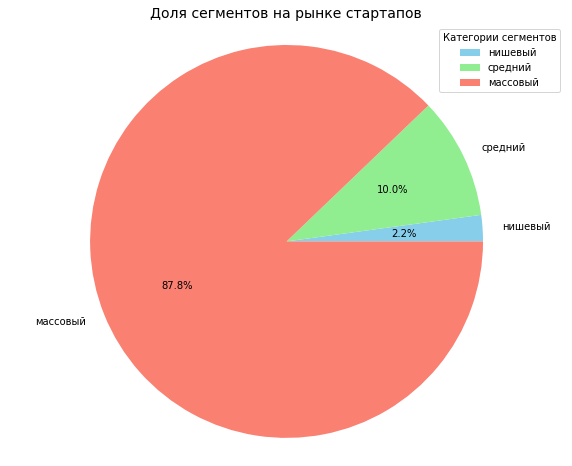

In [44]:
# Подсчитываем количество компаний в каждом сегменте
segment_counts = df['market'].value_counts()

# Определяем функцию для классификации сегментов
def classify_segment(count):
    if count > 120:
        return 'массовый'
    elif 35 <= count <= 120:
        return 'средний'
    else:
        return 'нишевый'

# Применяем классификацию к каждому сегменту
segment_categories = segment_counts.apply(classify_segment)

# Группируем counts по категориям и суммируем
grouped_counts = segment_counts.groupby(segment_categories).sum().sort_values()

print("Суммарное количество компаний по категориям:")
print(grouped_counts)

# Строим график
plt.figure(figsize=(8, 6))
bars = plt.bar(grouped_counts.index, grouped_counts.values)

plt.xlabel('Категории сегментов')
plt.ylabel('Суммарное количество компаний')
plt.title('Распределение компаний по категориям сегментов рынка')


plt.tight_layout()
plt.show()

# Строим круговую диаграмму, чтобы понять доли сегментов
plt.figure(figsize=(10, 8))
plt.pie(grouped_counts, labels=grouped_counts.index, colors=['skyblue', 'lightgreen', 'salmon'], autopct='%1.1f%%')
plt.axis('equal')  # чтобы круг был ровным
plt.title('Доля сегментов на рынке стартапов', fontsize=14)
plt.legend(title='Категории сегментов', loc='upper right')

plt.show()

Основные наблюдения:
- Доминирование массового сегмента
    - Чётко прослеживается явное лидерство массового сегмента — он превышает суммарное количество компаний из нишевого и среднего сегментов почти в 7 раз. Это говорит о высокой степени концентрации стартапов в массовых направлениях.

- Значимость среднего сегмента
    - Средний сегмент (3841 стартап) существенно превосходит нишевый по масштабам, что указывает на наличие большого числа проектов со сбалансированными характеристиками.

- Относительная малочисленность нишевых проектов
    - Нишевый сегмент с 830 компаниями выглядит наименее представленным, что характерно для узкоспециализированных направлений.

Возможные объяснения:
- Масштабные тренды 
    - Массовый сегмент отражает интерес к универсальным решениям, которые могут масштабироваться и охватывать широкую аудиторию
- Баланс инноваций и рисков
    - Средний сегмент объединяет проекты, которые уже доказали свою жизнеспособность, но не достигли уровня массового внедрения
- Специализация и уникальность
    - Нишевые стартапы фокусируются на узких проблемах, где сложнее добиться быстрого роста, но есть потенциал для глубокой экспертизы

Что это значит для развития рынка стартапов:
- Возможности для масштабирования
    - Большое количество массовых проектов создаёт здоровую конкуренцию и стимулирует инновации в популярных областях
- Потенциал среднего сегмента
    - Проекты этого уровня могут стать «кандидатами» в массовые, если найдут пути расширения аудитории
- Ниша для прорывных идей
    - Небольшое число нишевых компаний оставляет пространство для новых стартапов, которые могут занять незанятые рыночные сегменты
- Сбалансированная экосистема
    - Присутствие всех трёх категорий создаёт устойчивую структуру рынка: от узкоспециализированных решений до массовых продуктов

Оставьте в столбце `market` только массовые сегменты. Для остальных сегментов замените значения на заглушки — `niche` для нишевых и `mid` для средних.

Дальнейшие исследования выполняйте с учётом этой замены. Индивидуальные сегменты внутри средней и нишевой групп рассматривать не нужно — они объединяются в два общих сегмента.


In [45]:
df['market'].unique()

array(['Education', nan, 'Business Services', 'Social Media',
       'Hardware + Software', 'Biotechnology', 'Hospitality',
       'Enterprise Software', 'Manufacturing', 'Finance', 'Design',
       'Utilities', 'Nonprofits', 'Software', 'Curated Web',
       'Health Care', 'Pharmaceuticals', 'Health and Wellness', 'Media',
       'Politics', 'Clean Technology', 'Financial Services',
       'Consumer Electronics', 'Web Hosting', 'E-Commerce', 'Automotive',
       'Local Businesses', 'Medical', 'Fashion', 'Banking', 'Security',
       'Publishing', 'Networking', 'Analytics', 'Semiconductors',
       'Public Relations', 'Jewelry', 'Nanotechnology', 'Travel',
       'Public Transportation', 'Consulting', 'Real Estate',
       'Environmental Innovation', 'Retail', 'Restaurants', 'Services',
       'Technology', 'Telecommunications', 'Information Technology',
       'Music', 'Advertising', 'Payments', 'Games', 'Mobile',
       'Consumer Goods', 'Medical Devices', 'Human Resources',
       '

In [46]:
# Функция для замены значений

def replace_segments(original_value):
    # Проверяем на NaN
    if pd.isna(original_value):
        return original_value 

    count = segment_counts[original_value]
    
    if 35 <= count <= 120:
        return 'mid'
    elif count < 35:
        return 'niche'
    else:  
        return original_value

# Применяем функцию к столбцу market
df['market'] = df['market'].apply(replace_segments)

In [47]:
# Проверяем, что получилось. Остались массовые сегменты и добавились mid и niche
df['market'].unique()

array(['Education', nan, 'mid', 'Social Media', 'Hardware + Software',
       'Biotechnology', 'Hospitality', 'Enterprise Software',
       'Manufacturing', 'Finance', 'Design', 'niche', 'Nonprofits',
       'Software', 'Curated Web', 'Health Care', 'Health and Wellness',
       'Clean Technology', 'Web Hosting', 'E-Commerce', 'Automotive',
       'Medical', 'Fashion', 'Security', 'Networking', 'Analytics',
       'Semiconductors', 'Public Relations', 'Travel', 'Consulting',
       'Real Estate', 'Technology', 'Music', 'Advertising', 'Games',
       'Mobile', 'Internet', 'Sports', 'Photography', 'News', 'Search',
       'Messaging', 'Video', 'Marketplaces', 'Entertainment', 'SaaS',
       'Cloud Computing', 'Big Data', 'Apps', 'Social Network Media',
       'Startups'], dtype=object)

## Шаг 3. Работа с выбросами и анализ

### 3.1. Анализируем и помечаем выбросы в каждом из сегментов

Заказчика интересует обычный для рассматриваемого периода размер средств, который предоставлялся компаниям.

По предобработанному столбцу `funding_total_usd` графическим образом оцените, какой размер общего финансирования для одной компании будет типичным, а какой — выбивающимся. Укажите интервал, в котором лежат типичные значения.

In [48]:
print('Распределение данных по значениям столбца среднему чеку:')
df['funding_total_usd'].describe()

Распределение данных по значениям столбца среднему чеку:


count    4.090700e+04
mean     1.591252e+07
std      1.686788e+08
min      1.000000e+00
25%      3.500000e+05
50%      2.000000e+06
75%      1.000000e+07
max      3.007950e+10
Name: funding_total_usd, dtype: float64

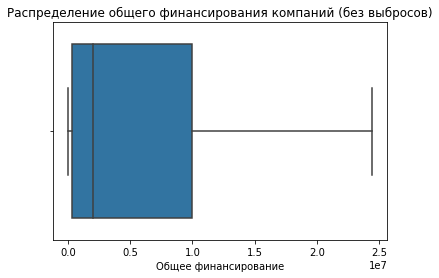

In [49]:
sns.boxplot(x=df['funding_total_usd'], showfliers=False)
plt.title('Распределение общего финансирования компаний (без выбросов)')
plt.xlabel('Общее финансирование')
plt.show()

`Наиболее типичное финансирование: вокруг медианы — 2 млн USD.
Интервал типичных значений: 0–24,5 млн USD.
Нетипичные (выбивающиеся): >24,5 млн USD, включая рекордные суммы вроде 30 млрд USD.`

Определите компании с аномальным объёмом общего финансирования — используйте метод IQR отдельно по каждому сегменту. Напомним, что все нишевые сегменты должны быть объединены в одну группу, а средние — в другую.

Определите сегменты рынка с наибольшей долей компаний, получивших аномальное финансирование, и выведите топ таких сегментов.

In [50]:
# Разбиваем данные на группы
grouped = df.groupby('market')

# Определяем аномальные значения финансирования по методу IQR для каждого сегмента
def find_outliers(group):
    Q1 = group['funding_total_usd'].quantile(0.25)
    Q3 = group['funding_total_usd'].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return (group['funding_total_usd'] < lower_bound) | (group['funding_total_usd'] > upper_bound)

outliers = grouped.apply(find_outliers)

# Подсчитываем долю аномальных компаний в каждом сегменте
outlier_ratio = outliers.mean(level=0)

# Выводим топ сегментов с наибольшей долей аномального финансирования
top_outlier_segments = outlier_ratio.sort_values(ascending=False).head(5)
print(top_outlier_segments) 

market
Real Estate        0.172043
Entertainment      0.166667
Consulting         0.166189
Search             0.164948
Cloud Computing    0.164474
Name: funding_total_usd, dtype: float64


Из предоставленного списка сегментов рынка и долей компаний с аномальным объёмом финансирования можно сделать следующие выводы:
- Real Estate: доля компаний с аномальным финансированием составляет 17,20%. Это самый высокий показатель среди перечисленных сегментов.
- Entertainment: доля аномальных компаний — 16,67%. Это немного меньше, чем у сегмента Real Estate, но всё равно достаточно высокий процент.
- Consulting: доля — 16,62%. Практически совпадает с сегментом Entertainment.
- Search: доля — 16,49%. Немного ниже предыдущих двух сегментов, но всё ещё значительна.
- Cloud Computing: доля — 16,45%. Наименьший показатель среди перечисленных, но всё же остаётся высоким.

Общий вывод:
- Все перечисленные сегменты имеют довольно высокие доли компаний с аномальными объёмами финансирования. Это может указывать на то, что в этих секторах присутствуют значительные различия в объёмах привлекаемого капитала, возможно, из-за разной степени конкуренции, потенциала роста или специфических потребностей финансирования.

### 3.2 Определяем границы рассматриваемого периода, отбрасываем аномалии

Проверьте по датасету, можно ли считать, что вам предоставили полные данные за 2014 год. Затем исключите из датасета компании, которые вы ранее посчитали получившими аномальное финансирование.

Когда исключите аномальные записи, на основе столбцов `mid_funding_at` и `funding_rounds` оставьте в датасете данные только об определённых компаниях. Они должны были получать финансирование в годы, когда было зафиксировано 50 или более раундов финансирования.

In [51]:
#  Проверка полноты данных за 2014 год
filtered_2014 = df[df['mid_funding_at'].dt.year == 2014]

print(f"Количество записей за 2014 год: {len(filtered_2014)}")

# Смотрим минимальную и максимальную дату в выборке за 2014
min_date_2014 = filtered_2014['mid_funding_at'].min()
max_date_2014 = filtered_2014['mid_funding_at'].max()

print(f"Самая ранняя запись за 2014: {min_date_2014}")
print(f"Самая поздняя запись за 2014: {max_date_2014}")

Количество записей за 2014 год: 6619
Самая ранняя запись за 2014: 2014-01-01 00:00:00
Самая поздняя запись за 2014: 2014-12-31 00:00:00


`Так как есть данный за последний день декабря то данные видимо не обрезаны`

In [52]:
#  Исключение компаний с аномальным финансированием
# Преобразуем outliers в плоский массив булевых значений, совместимый с df
outliers_flat = outliers.reset_index(level=0, drop=True)  # сбрасываем группирующий индекс
outliers_bool = outliers_flat.reindex(df.index, fill_value=False)  # совмещаем с индексом df

# Исключаем аномальные записи (оставляем только НЕ-аномалии)
df = df[~outliers_bool]

print(f"\nКоличество записей после удаления аномалий: {len(df)}")


Количество записей после удаления аномалий: 36036


In [53]:
#  Фильтрация компаний по количеству раундов финансирования в год

# Группируем данные по годам и считаем количество раундов финансирования
annual_rounds = df.groupby(df['mid_funding_at'].dt.year)['funding_rounds'].count()
print("\nКоличество раундов финансирования по годам:")
print(annual_rounds)



Количество раундов финансирования по годам:
mid_funding_at
1921.0       1
1960.0       2
1979.0       1
1982.0       3
1983.0       1
1984.0       2
1985.0       3
1987.0       2
1989.0       1
1990.0       1
1992.0       4
1993.0       1
1994.0       4
1995.0       4
1996.0       3
1997.0       4
1998.0       9
1999.0      30
2000.0      68
2001.0      43
2002.0      53
2003.0      64
2004.0     101
2005.0     705
2006.0    1180
2007.0    1606
2008.0    1999
2009.0    2657
2010.0    3513
2011.0    4334
2012.0    5563
2013.0    7872
2014.0    6201
Name: funding_rounds, dtype: int64


In [55]:
df = df[df['mid_funding_at'].dt.year >= 2000]

# Получаем список уникальных годов из отфильтрованного датасета
years_after_2000 = df['mid_funding_at'].dt.year.unique()

# Выводим отобранные годы
print("\nГоды после 2000:")
print(sorted(years_after_2000))  # сортируем для наглядности

# Печатаем итоговое количество записей
print(f"\nКоличество записей после фильтрации: {len(df)}")


Годы после 2000:
[2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014]

Количество записей после фильтрации: 35959


### 3.3. Анализ типов финансирования по объёму и популярности

Постройте график, который покажет, какие типы финансирования в сумме привлекли больше всего денег. Ориентируйтесь на значения в столбцах `seed`, `venture`, `equity_crowdfunding`, `undisclosed`, `convertible_note`, `debt_financing`, `angel`, `grant`, `private_equity`, `post_ipo_equity`, `post_ipo_debt`, `secondary_market` и `product_crowdfunding`.

Также постройте график, который покажет популярность разных типов финансирования — какие типы финансирования чаще всего используются компаниями, то есть встречаются в датасете наибольшее количество раз.

Сравните графики и выделите часто используемые типы финансирования, которые при этом характеризуются небольшими объёмами, и наоборот — те, что встречаются редко, но при этом характеризуются значительным объёмом предоставленных сумм.

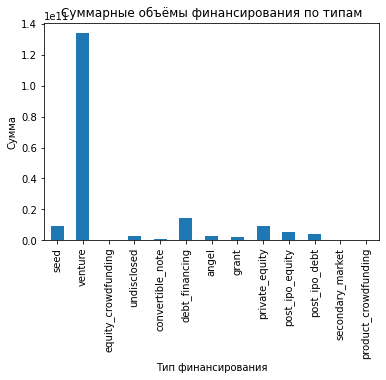

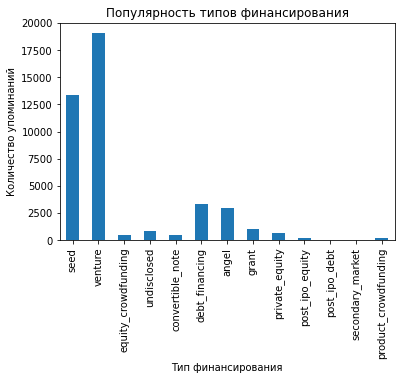

Типы финансирования с наибольшими суммарными объёмами:
venture                 1.339872e+11
debt_financing          1.430518e+10
seed                    9.494128e+09
private_equity          9.262413e+09
post_ipo_equity         5.099300e+09
post_ipo_debt           4.286719e+09
undisclosed             2.924353e+09
angel                   2.501264e+09
grant                   2.168262e+09
convertible_note        5.671449e+08
equity_crowdfunding     2.629607e+08
product_crowdfunding    1.933103e+08
secondary_market        1.240861e+08
dtype: float32

Типы финансирования, наиболее часто встречающиеся:
venture                 19060
seed                    13388
debt_financing           3312
angel                    2938
grant                    1020
undisclosed               834
private_equity            680
convertible_note          522
equity_crowdfunding       516
product_crowdfunding      205
post_ipo_equity           177
post_ipo_debt              29
secondary_market            8
dtype: 

In [56]:
# Подсчитываем суммарные объёмы финансирования по каждому типу
total_funding = df[['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note',
                    'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity',
                    'post_ipo_debt', 'secondary_market', 'product_crowdfunding']].sum()

# Строим график суммарных объёмов финансирования
total_funding.plot(kind='bar')
plt.title('Суммарные объёмы финансирования по типам')
plt.xlabel('Тип финансирования')
plt.ylabel('Сумма')
plt.show()

# Подсчитываем количество упоминаний каждого типа финансирования
popularity = df[['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note',
                 'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity',
                 'post_ipo_debt', 'secondary_market', 'product_crowdfunding']].astype(bool).sum()

# Строим график популярности типов финансирования
popularity.plot(kind='bar')
plt.title('Популярность типов финансирования')
plt.xlabel('Тип финансирования')
plt.ylabel('Количество упоминаний')
plt.show()

# Сравнение графиков и выделение типов финансирования
print("Типы финансирования с наибольшими суммарными объёмами:")
print(total_funding.sort_values(ascending=False))

print("\nТипы финансирования, наиболее часто встречающиеся:")
print(popularity.sort_values(ascending=False))


Типы с наибольшими суммарными объёмами финансирования
- Лидерами по объёмам привлечённых средств являются:
    - Venture — абсолютный лидер с суммой порядка 133,9 млрд. Это говорит о высокой активности венчурного финансирования в экосистеме стартапов.
    - Debt financing (14,3 млрд) и seed (9,49 млрд) — также крупные сегменты, отражающие значимость начального финансирования и заёмных средств.
    - Private equity (9,26 млрд) демонстрирует важность финансирования от частных инвестиционных фондов.
    - Средние объёмы показывают: - post_ipo_equity (5,1 млрд); - post-ipo debt (4,29 млрд); - undisclosed (2,92 млрд); - angel (2,5 млрд); - grant (2,17 млрд).
    - Наименьшие объёмы у: - convertible_note (567 млн); - equity crowdfunding (262,9 млн); - product crowdfunding (193,3 млн); - secondary market (124,1 млн).
    
Наиболее популярные типы финансирования (по количеству упоминаний)
- Самые часто используемые типы:
    - Venture (19 060) — безусловный лидер по частоте использования, что подтверждает его роль как основного канала финансирования стартапов.
    - Seed (13 388) занимает второе место, подчёркивая важность начального раунда привлечения средств.
    - Debt financing (3 312) и angel (2 938) также демонстрируют высокую востребованность.
    - Менее популярные варианты: - grant (1 020); - undisclosed (834); - private equity (680).
    - Редко используемые: - convertible note (522); - equity crowdfunding (516); - product crowdfunding (205); - post_ipo_equity (177); - post ipo debt (29); - secondary market (8).
    
Сравнение и выводы
- Часто используемые типы с небольшими объёмами: - Angel: часто используется (2 938 раз), но средний объём сделок невелик (2,5 млрд). - Grant: также относительно часто упоминается (1 020 раз), объёмы — 2,17 млрд.
- Редко используемые, но с большими объёмами: - Post ipo equity: встречается редко (177 раз), но суммарные объёмы достигают 5,1 млрд. - Debt financing: 3 312 упоминаний, но общий объём — 14,3 млрд, что подчёркивает значимость крупных сделок в этом сегменте.
- В целом, данные демонстрируют разнообразие источников финансирования стартапов, где венчурное и начальное финансирование играют ключевые роли как по объёмам, так и по частоте использования.

Постройте график суммарных объёмов возвратов от разных типов финансирования за весь период на основе дополнительного датасета.

Типы финансирования с наибольшими суммарными объёмами:
venture                 40578.617188
debt_financing           4734.850098
private_equity           3587.330078
seed                     2382.239990
angel                    1509.229980
post_ipo_equity          1104.959961
undisclosed               730.880005
post_ipo_debt              91.029999
convertible_note           34.790001
secondary_market            5.200000
equity_crowdfunding         3.830000
product_crowdfunding        1.860000
grant                       0.000000
dtype: float32


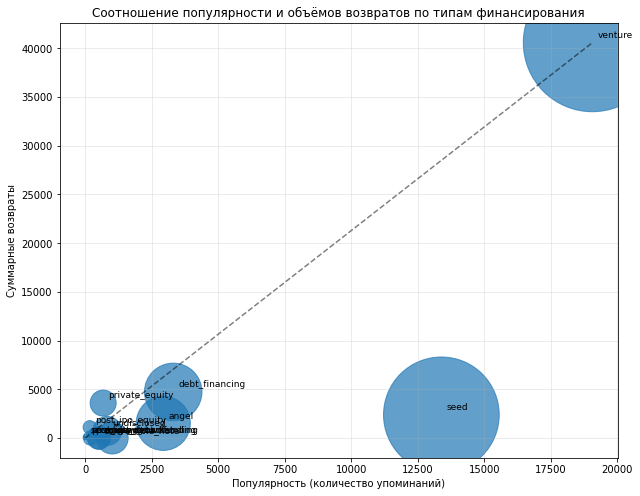

In [57]:
# Подсчитываем суммарные объёмы финансирования по каждому типу
total_funding_ret = df_ret[['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note',
                    'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity',
                    'post_ipo_debt', 'secondary_market', 'product_crowdfunding']].sum()

print("Типы финансирования с наибольшими суммарными объёмами:") 
print(total_funding_ret.sort_values(ascending=False))

# Создаём scatter-график
plt.figure(figsize=(10, 8))
scatter = plt.scatter(popularity.values, total_funding_ret.values, 
                     s=popularity.values,  # Размер точки зависит от популярности
                     alpha=0.7)

plt.xlabel('Популярность (количество упоминаний)')
plt.ylabel('Суммарные возвраты')
plt.title('Соотношение популярности и объёмов возвратов по типам финансирования')

# Добавляем диагональную линию для сравнения
plt.plot([0, max(popularity)], [0, max(total_funding_ret)], 'k--', alpha=0.5)

# Подписываем типы финансирования
for i, label in enumerate(popularity.index):
    plt.annotate(label, (popularity[i], total_funding_ret[i]), xytext=(5, 5), 
                 textcoords='offset points', fontsize=9)

plt.grid(True, alpha=0.3)
plt.show()

Лидеры по объёмам возвратов: 
- Venture — абсолютный лидер с объёмом возвратов 40 578,62. Это подтверждает статус венчурного финансирования как основного источника крупных возвратов в экосистеме стартапов.
- Debt financing (4 734,85) и private equity (3 587,33) — стабильно крупные объёмы возвратов, что указывает на значимость заёмного капитала и инвестиций от частных фондов. 
- Seed (2 382,24) и angel (1 509,23) демонстрируют важность начального финансирования и ангельских инвестиций.

Средние объёмы возвратов: 
- Post_ipo_equity (1 104,96)
- Undisclosed (730,88)
Эти типы показывают устойчивую отдачу, хотя и уступают лидерам.

Низкообъёмные типы: 
- Post_ipo_debt (91,03) — относительно небольшие возвраты, что может говорить о специфике этого сегмента 
- Convertible_note (34,79) — очень скромные объёмы, возможно, из‑за ограниченной распространённости или условий конвертации 
- Secondary_market (5,20), equity_crowdfunding (3,83), product_crowdfunding (1,86) — крайне низкие показатели возвратов. Это может быть связано либо с малым числом сделок, либо с особенностями механизмов этих типов финансирования.

- Grant показал 0 возвратов. Возможные причины: - гранты могут не предполагать возврата средств.

Стоит отметить, что `seed` занимает 2 место по популярности, но количество возвратов, хоть и входит в топ5, но очень маленькое.

Также стоит отметить `private_equity`, ведь он более объёмный, нежели популярный.

## Шаг 4. Анализ динамики

### 4.1 Динамика предоставления финансирования по годам

Используя столбцы `funding_total_usd` и `funding_rounds`, рассчитайте для каждой компании средний объём одного раунда финансирования.

На основе получившейся таблицы постройте графики, отражающие:
* динамику типичного размера средств, которые стартапы получали в рамках одного раунда финансирования;

* динамику общего количества раундов за каждый год, то есть насколько активно происходили инвестиции на рынке (чем больше раундов, тем выше активность).

Когда будете строить графики в этом задании и следующих, используйте данные только по тем компаниям, которые остались в датасете после предыдущих фильтраций.

На основе полученных данных ответьте на вопросы:
* В каком году типичный размер средств, собранных в рамках одного раунда, был максимальным?

* Какая тенденция наблюдалась в 2014 году по количеству раундов и средств, выделяемых в рамках каждого раунда?

In [58]:
# Рассчитать средний объём раунда для каждой компании:
df['year'] = df['mid_funding_at'].dt.year
df['avg_funding_per_round'] = df['funding_total_usd'] / df['funding_rounds']
# Типичный размер средств за раунд по годам (среднее значение avg_funding_per_round)
typical_round_size = df.groupby('year')['avg_funding_per_round'].mean()

# Общее количество раундов (активность рынка) по годам
round_activity = df.groupby('year').size()

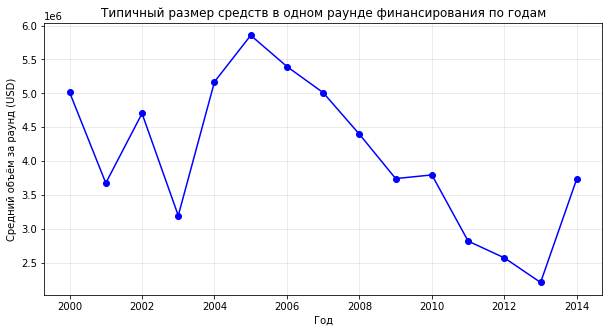

In [59]:
# График 1: динамика типичного размера раунда
plt.figure(figsize=(10, 5))
typical_round_size.plot(kind='line', marker='o', color='blue')
plt.title('Типичный размер средств в одном раунде финансирования по годам')
plt.xlabel('Год')
plt.ylabel('Средний объём за раунд (USD)')
plt.grid(True, alpha=0.3)
plt.show()

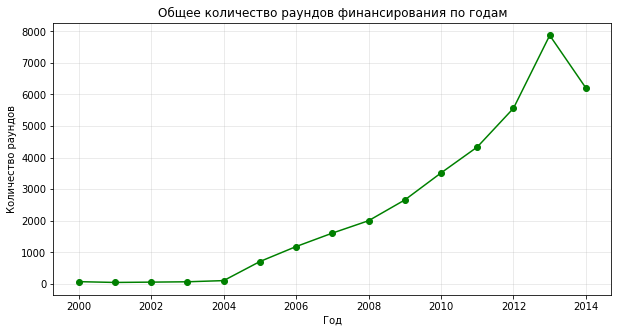

In [60]:
# График 2: динамика количества раундов
plt.figure(figsize=(10, 5))
round_activity.plot(kind='line', marker='o', color='green')
plt.title('Общее количество раундов финансирования по годам')
plt.xlabel('Год')
plt.ylabel('Количество раундов')
plt.grid(True, alpha=0.3)
plt.show()

In [61]:
# Год с максимальным типичным размером раунда
max_year = typical_round_size.idxmax()
print(f"Год с максимальным размером раунда: {max_year}")

Год с максимальным размером раунда: 2005


In [62]:
round_activity_2014 = round_activity[2014]
typical_round_2014 = typical_round_size[2014]
print(f"Количество раундов в 2014 году: {round_activity_2014}")
print(f"Типичный размер раунда в 2014 году: {typical_round_2014:.2f}")

Количество раундов в 2014 году: 6201
Типичный размер раунда в 2014 году: 3741691.75


### 4.2 Динамика размера общего финансирования по массовым сегментам рынка для растущих в 2014 году сегментов

Составьте сводную таблицу, в которой указывается суммарный размер общего финансирования `funding_total_usd` по годам и сегментам рынка. Отберите из неё только те сегменты, которые показывали рост размера суммарного финансирования в 2014 году по сравнению с 2013.

На графике отразите, как менялся суммарный размер общего финансирования в каждом из отобранных сегментов по годам, за которые у вас достаточно данных. Рассматривайте только массовые сегменты, а средние и нишевые исключите.

На основе графика сделайте вывод о том, какие сегменты показывают наиболее быстрый и уверенный рост.

<Figure size 1152x648 with 0 Axes>

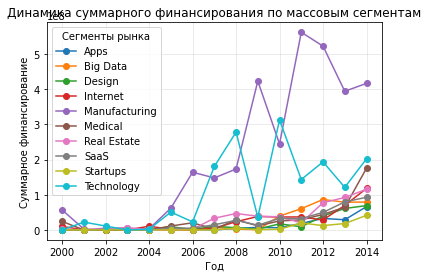

In [63]:
segment_summary = df.groupby(['year', 'market'])['funding_total_usd'].sum().unstack(fill_value=0)

funding_2013 = segment_summary.loc[2013]
funding_2014 = segment_summary.loc[2014]
growing_segments = funding_2014[funding_2014 > funding_2013].index

mass_segments = ['Education', 'Social Media', 'Hardware + Software',
       'Biotechnology', 'Hospitality', 'Enterprise Software',
       'Manufacturing', 'Finance', 'Design', 'Nonprofits',
       'Software', 'Curated Web', 'Health Care', 'Health and Wellness',
       'Clean Technology', 'Web Hosting', 'E-Commerce', 'Automotive',
       'Medical', 'Fashion', 'Security', 'Networking', 'Analytics',
       'Semiconductors', 'Public Relations', 'Travel', 'Consulting',
       'Real Estate', 'Technology', 'Music', 'Advertising', 'Games',
       'Mobile', 'Internet', 'Sports', 'Photography', 'News', 'Search',
       'Messaging', 'Video', 'Marketplaces', 'Entertainment', 'SaaS',
       'Cloud Computing', 'Big Data', 'Apps', 'Social Network Media',
       'Startups']
selected_segments = growing_segments.intersection(mass_segments)
filtered_summary = segment_summary[selected_segments]

# Шаг 4: Построение графика динамики
plt.figure(figsize=(16, 9))
filtered_summary.plot(kind='line', marker='o')
plt.title('Динамика суммарного финансирования по массовым сегментам')
plt.xlabel('Год')
plt.ylabel('Суммарное финансирование')
plt.legend(title='Сегменты рынка')
plt.grid(True, alpha=0.3)
plt.show() 

По сравнению с 2013 в 2014 году рост показало лишь 18 из 48 массовых сегментов рынка. 

Наиболее быстрый рост показали `Manufacturing` и `Technology`. У `Manufacturing` наблюдается падение показателей в период с 2099 по 2010 года, но впоследствии показатели взлетели, а вот у `Technology` была значительная просадка в период с 2008 по 2009 год и возвращение показателей ближе к 2010 году.

### 4.3 Годовая динамика доли возвращённых средств по типам финансирования

Заказчик хочет знать, какая часть вложенных или выданных денег со временем возвращается обратно инвесторам или финансистам. Ваша цель — для каждого года и каждого вида финансирования рассчитать нормированные значения возврата средств: то есть какую долю возвращённые средства составляют от предоставленных. При этом слишком большие аномальные значения, то есть неадекватные выбросы, нужно заменить на пропуски.

Совет: когда будете делить сумму возвращённых средств на суммарный объём привлечённого финансирования по конкретному году, добавьте к знаменателю небольшое число, например `1e-60`. Это поможет избежать деления на ноль.

          seed   venture  equity_crowdfunding  undisclosed  convertible_note  \
year                                                                           
2000  0.996471  0.147591                  NaN     0.362919               NaN   
2001  0.109095  0.082357                  NaN     0.462126          0.006667   
2002  0.629707  0.611690                  NaN     0.608878               NaN   
2003  0.505276  0.584308                  NaN     0.914397               NaN   
2004  0.548476  0.768862                  NaN     0.336073               NaN   
2005  0.674695  0.536192                  NaN     1.071992               NaN   
2006  0.925372  0.336951             0.203632     0.650586          0.150747   
2007  0.366153  0.295054                  NaN     0.504971          0.228097   
2008  0.297083  0.187573                  NaN     0.285286          0.059788   
2009  0.563423  0.164277             0.087819     0.376177          0.054535   
2010  0.525605  0.184560             0.0

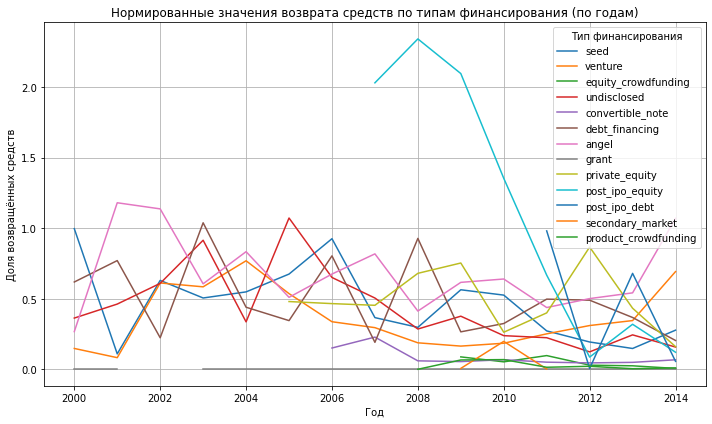

In [64]:
# Группируем данные по годам для возвратов
returns_by_year = df_ret.groupby('year').sum()

# Группируем данные по годам для инвестиций
investments_by_year = df.groupby('year')[['seed', 'venture', 'equity_crowdfunding', 
                                          'undisclosed', 'convertible_note', 'debt_financing',
                                          'angel', 'grant', 'private_equity', 'post_ipo_equity',
                                          'post_ipo_debt', 'secondary_market', 'product_crowdfunding']].sum()

# Создаем список типов финансирования для выравнивания
funding_types = [
    'seed', 'venture', 'equity_crowdfunding', 'undisclosed', 
    'convertible_note', 'debt_financing', 'angel', 'grant',
    'private_equity', 'post_ipo_equity', 'post_ipo_debt', 
    'secondary_market', 'product_crowdfunding'
]

# Приводим данные к одинаковому набору колонок
returns_aligned = returns_by_year[funding_types]
investments_aligned = investments_by_year[funding_types]

returns_aligned *= 1_000_000
# Рассчитываем нормированные значения возврата средств
return_ratios = returns_aligned / (investments_aligned + 1e-60)

# Обрабатываем аномальные значения
return_ratios[return_ratios > 10] = float('nan')

print(return_ratios)

# Строим график
return_ratios.plot(kind='line', figsize=(10, 6))
plt.title('Нормированные значения возврата средств по типам финансирования (по годам)')
plt.ylabel('Доля возвращённых средств')
plt.xlabel('Год')
plt.grid(True)
plt.legend(title='Тип финансирования')
plt.tight_layout()
plt.show()

Постройте график, на котором отобразите нормированные значения возврата средств для типов финансирования `venture`, `debt_financing`, `private_equity`, `seed` и `angel`.

Сделайте вывод о том, в каких типах финансирования наблюдается наиболее устойчивый рост показателя.

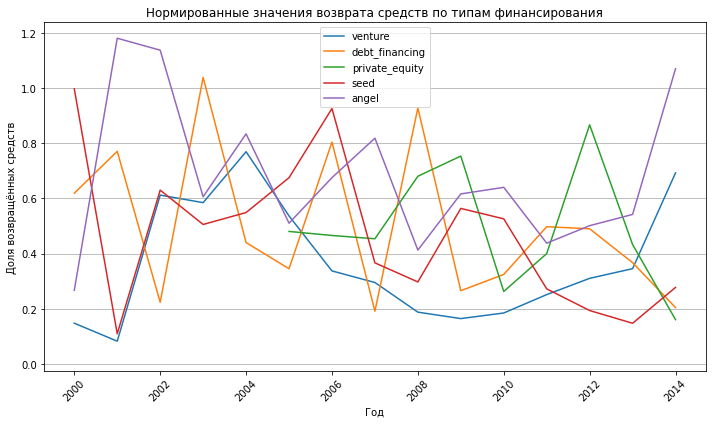

In [65]:
# Отбираем только нужные типы финансирования для графика
selected_types = ['venture', 'debt_financing', 'private_equity', 'seed', 'angel']

return_ratios_selected = return_ratios[selected_types]

# Строим график
return_ratios_selected.plot(kind='line', figsize=(10, 6))
plt.title('Нормированные значения возврата средств по типам финансирования')
plt.ylabel('Доля возвращённых средств')
plt.xlabel('Год')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

Наиболее устойчивый рост наблюдается у `venture` и `angel`. У `venture` была сильная просадка в период с 2004 по 2010, но значения вернулись в норму уже в 2014 году. У `angel` наблюдается чередование падений и взлетов, но после 2011 года у неё лишь взлеты показателей.


## Шаг 5. Итоговый вывод и рекомендации

Представьте, что на календаре 2015 год. Опираясь на результаты анализа, дайте рекомендацию заказчику:

* в какую отрасль стоит инвестировать;
* какой тип финансирования при этом будет наиболее уместным.

Подведите итоги проекта:
* опишите, какие шаги были выполнены;
* какие выводы удалось сделать;
* насколько выводы согласуются между собой или, наоборот, вызывают сомнения.



`По данным стоит отметить долговое финансирование. Оно наиболее устойчивое в плане возврата, поэтому разница между потраченными и полученными деньгами будет невелика.`

`Тип финансирования бы выбрал финансирование до года, по той причине, что даже при своей устойчивости, потеря денег может быть вполне возможна.`

Шаги:
- Познакомились с данными и преодобработали их
- Сделали инжиринг признаков
- Сделали работу с выбросами и проанализировали их
- Провели анализ динамики

- Доля компаний по группам финансирования:
    - около 59% у Единичного финансирования
    - около 30% у Срока финансирования более года
    - около 11% у Срока финасирования до года
- Распределение объёма инвестиций по группам:
    - около 61.9% у Срока финасирования более года
    - около 30.6% у Единичного финасирования
    - около 7.5% у Срока финансирования до года

- Большую часть рынка занимает массовая категория сегмента с 33733 компаний, потом идёт средняя с 3841, а в конце нишевая с 830.

- Наиболее типичное финансирование: вокруг медианы — 2 млн USD.
    Интервал типичных значений: 0–24,5 млн USD.
    Нетипичные (выбивающиеся): >24,5 млн USD, включая рекордные суммы вроде 30 млрд USD

- Самый большой объем финансирования идёт от венчурных инвестиций, так и больше всего сумма возвратов у венчурных инвестиций, причём с большим отрывом

- Год с максимальным размером раунда: 2005

- Тенденции в 2014 году:
    - Количество раундов в 2014 году: 6201
    - Типичный размер раунда в 2014 году: 3741691.75
    
- Наиболее устойчивый рост наблюдается у `venture` и `angel`.